### 导入依赖库与数据读取

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# ==========================================# 1. 数据装载 # ==========================================#
df_cpu = pd.read_csv("/Users/macbookpro/Desktop/Project/软件测试与维护/大作业/jiaoben/80用户/jmeter80用户整体总负载与整体平均CPU使用率-data-as-joinbyfield-2026-06-14 18_52_03.csv")         # 整体总负载与整体平均CPU使用率
df_net_bw = pd.read_csv("/Users/macbookpro/Desktop/Project/软件测试与维护/大作业/jiaoben/80用户/jmeter80用户每秒网络带宽使用eth0-data-as-joinbyfield-2026-06-14 18_53_18.csv")      # 每秒带宽使用
df_socket = pd.read_csv("/Users/macbookpro/Desktop/Project/软件测试与维护/大作业/jiaoben/80用户/jmeter80用户网络Socket连接信息-data-as-joinbyfield-2026-06-14 18_53_00.csv")         # 网络socket连接信息except FileNotFoundError as e:

### 多维特征按时间对齐与拼接

In [11]:
# ==========================================# 2. 特征融合 (Feature Fusion)# ==========================================#
df_cpu['Time'] = pd.to_datetime(df_cpu['Time'])
df_net_bw['Time'] = pd.to_datetime(df_net_bw['Time'])
df_socket['Time'] = pd.to_datetime(df_socket['Time'])

# 按照 Time 列进行内连接合并
df_merged = pd.merge(df_cpu, df_net_bw, on="Time")
df_merged = pd.merge(df_merged, df_socket, on="Time")

print("多维特征拼接完成！当前的特征矩阵维度为:", df_merged.shape)

多维特征拼接完成！当前的特征矩阵维度为: (50, 14)


### 严格对齐时间轴打标签

In [12]:
# ==========================================# 3. 科学打标签 (Labeling)# ==========================================#
df_merged['label'] = 0
poison_start = pd.to_datetime("2026-06-14 18:41:00")
poison_end = pd.to_datetime("2026-06-14 18:51:00")

df_merged.loc[(df_merged['Time'] >= poison_start) & (df_merged['Time'] <= poison_end), 'label'] = 1

print("正常 vs 异常样本分布:\n", df_merged['label'].value_counts())

正常 vs 异常样本分布:
 label
0    28
1    22
Name: count, dtype: int64


### 清洗数据

In [13]:
def clean_all_units(val):
    if pd.isna(val):
        return 0.0
    
    val_str = str(val).strip().lower()
    try:
        for suffix in ['kb/s', 'mb/s', 'b/s', 'kb', 'mb', 'b', '/s', 's', '%']:
            val_str = val_str.replace(suffix, '')
        
        if val_str.endswith('m'):
            val_str = val_str[:-1].strip()
            
        if not val_str:
            return 0.0
            
        pure_num = float(val_str)
        
        # 针对大流量网络带宽的换算
        original_val = str(val).lower()
        if 'm' in original_val and 'mb' in original_val:
            return pure_num * 1024.0
        elif 'b' in original_val and 'k' not in original_val:
            return pure_num / 1024.0
            
        return pure_num
    except:
        return 0.0

### 提取特征

In [14]:
features = [col for col in df_merged.columns if col not in ['Time', 'label']]
for col in features:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].apply(clean_all_units)

print("所有特征列的单位（包括 kb/s、%）已全部清洗完毕")

X = df_merged[features]
y = df_merged['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

所有特征列的单位（包括 kb/s、%）已全部清洗完毕


### 训练模型与预测

In [15]:
# ==========================================# 5. 孤立森林模型训练与预测# ==========================================#
model = IsolationForest(contamination=0.4, random_state=42)
model.fit(X_scaled)

raw_preds = model.predict(X_scaled)
y_pred = np.where(raw_preds == -1, 1, 0)

### 输出指标并画图


机器学习异常检测评估报告:
              precision    recall  f1-score   support

      Normal       0.47      0.50      0.48        28
     Anomaly       0.30      0.27      0.29        22

    accuracy                           0.40        50
   macro avg       0.38      0.39      0.38        50
weighted avg       0.39      0.40      0.40        50

ROC-AUC 核心得分: 0.3864


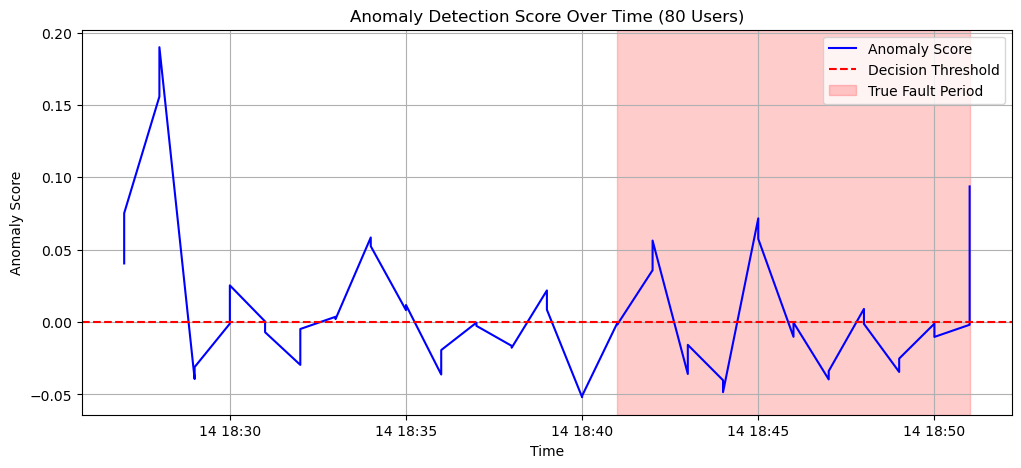

In [16]:
# ==========================================# 6. 成果输出与评估 # ==========================================
print("\n机器学习异常检测评估报告:")
print(classification_report(y, y_pred, target_names=['Normal', 'Anomaly']))

# 计算 AUC 得分
auc_score = roc_auc_score(y, y_pred)
print(f"ROC-AUC 核心得分: {auc_score:.4f}")

# 画出异常检测得分时序图
df_merged['anomaly_score'] = -model.decision_function(X_scaled) # 分数越高越异常

plt.figure(figsize=(12, 5))
plt.plot(df_merged['Time'], df_merged['anomaly_score'], label='Anomaly Score', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Decision Threshold')
plt.axvspan(poison_start, poison_end, color='red', alpha=0.2, label='True Fault Period')
plt.title("Anomaly Detection Score Over Time (80 Users)")
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.legend()
plt.grid(True)
plt.savefig("detection_result_80.png", dpi=300)
plt.show()